📝 Notebook: Palm_Oil_Production_Prediction.ipynb

1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

2. Load and Merge Data

In [2]:
# Load CSV files
land_use_df = pd.read_csv("land-use-palm-oil.csv")
production_df = pd.read_csv("palm-oil-production.csv")

# Rename columns
land_use_df.columns = ['Entity', 'Code', 'Year', 'Area_Harvested_ha']
production_df.columns = ['Entity', 'Code', 'Year', 'Production_tonnes']

# Merge datasets
merged_df = pd.merge(land_use_df, production_df, on=['Entity', 'Year'], how='inner')
merged_df = merged_df.drop(columns=['Code_x', 'Code_y']).dropna()


3. Preprocessing

In [3]:
# Encode categorical 'Entity'
le = LabelEncoder()
merged_df['Entity_encoded'] = le.fit_transform(merged_df['Entity'])

# Select features and target
X = merged_df[['Entity_encoded', 'Year', 'Area_Harvested_ha']]
y = merged_df['Production_tonnes']

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


4. Model Training

In [4]:
etr = ExtraTreesRegressor(random_state=42)
ada = AdaBoostRegressor(random_state=42)

etr.fit(X_train, y_train)
ada.fit(X_train, y_train)

etr_pred = etr.predict(X_test)
ada_pred = ada.predict(X_test)


5. Evaluation Metrics

In [5]:
def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "RMSLE": np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))
    }

etr_metrics = evaluate(y_test, etr_pred)
ada_metrics = evaluate(y_test, ada_pred)

print("📊 Extra Trees Metrics:", etr_metrics)
print("📊 AdaBoost Metrics:", ada_metrics)


📊 Extra Trees Metrics: {'R2': 0.9945725548074702, 'MAE': 133160.96496795365, 'MSE': 341819165652.74286, 'RMSE': 584653.0301407347, 'MAPE': 7847689627250679.0, 'RMSLE': 0.5007767905681405}
📊 AdaBoost Metrics: {'R2': 0.9557011739432094, 'MAE': 771333.621194595, 'MSE': 2789929188593.061, 'RMSE': 1670308.1118742917, 'MAPE': 4.710565634898063e+19, 'RMSLE': 3.606675027818669}


6. Residual Analysis & Feature Importance

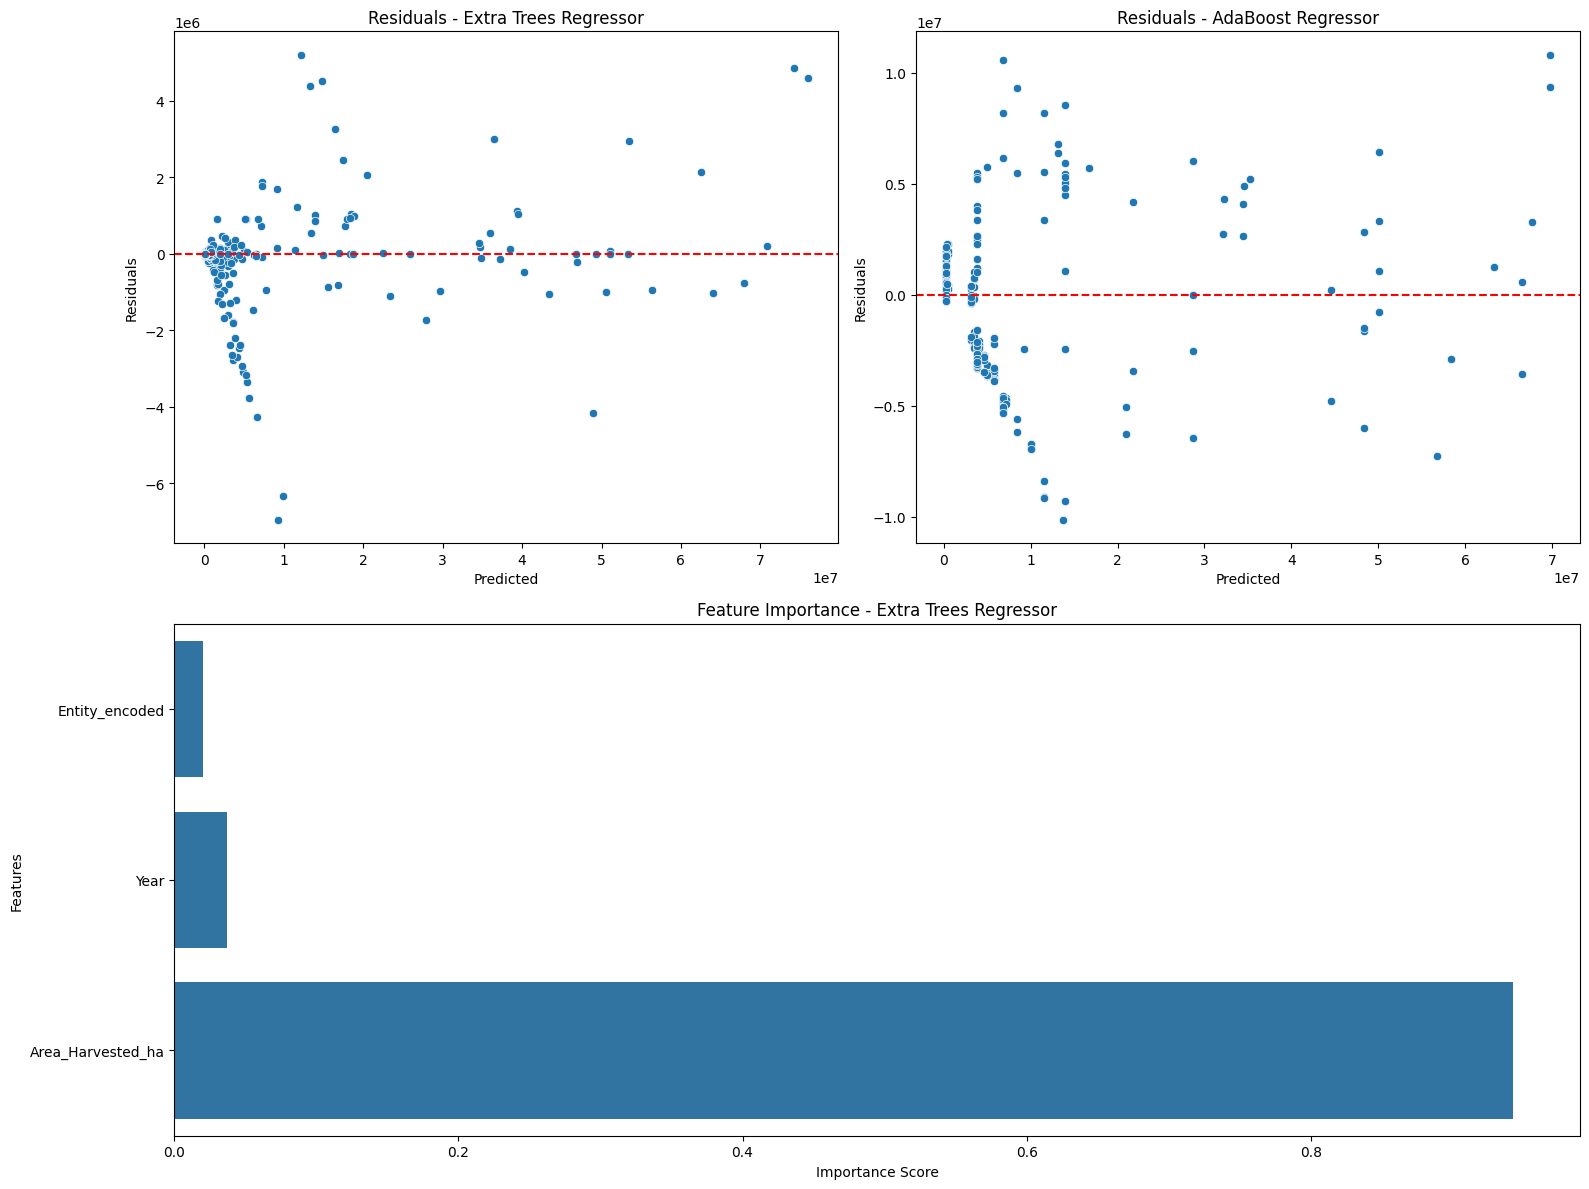

In [6]:
etr_residuals = y_test - etr_pred
ada_residuals = y_test - ada_pred

etr_importances = etr.feature_importances_
feature_names = ['Entity_encoded', 'Year', 'Area_Harvested_ha']

plt.figure(figsize=(16, 12))

# Residuals - Extra Trees
plt.subplot(2, 2, 1)
sns.scatterplot(x=etr_pred, y=etr_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals - Extra Trees Regressor')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

# Residuals - AdaBoost
plt.subplot(2, 2, 2)
sns.scatterplot(x=ada_pred, y=ada_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals - AdaBoost Regressor')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

# Feature Importance
plt.subplot(2, 1, 2)
sns.barplot(x=etr_importances, y=feature_names)
plt.title('Feature Importance - Extra Trees Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()
